In [ ]:
Capstone project 2
Project Title: Credit card fraud detection
Submitted by: Trupti Tanaya Mishra
Batch 12

In [4]:
# Basic
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ML Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Metrics
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Imbalance handling
from imblearn.over_sampling import SMOTE

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Hyperparameter tuning
import keras_tuner as kt

In [14]:
df = pd.read_csv("creditcard.csv").sample(50000, random_state=42)

print(df.head())
print(df.info())

            Time         V1        V2         V3        V4         V5  \
43428    41505.0 -16.526507  8.584972 -18.649853  9.505594 -13.793819   
49906    44261.0   0.339812 -2.743745  -0.134070 -1.385729  -1.451413   
29474    35484.0   1.399590 -0.590701   0.168619 -1.029950  -0.539806   
276481  167123.0  -0.432071  1.647895  -1.669361 -0.349504   0.785785   
278846  168473.0   2.014160 -0.137394  -1.015839  0.327269  -0.182179   

              V6         V7        V8        V9  ...       V21       V22  \
43428  -2.832404 -16.701694  7.517344 -8.507059  ...  1.190739 -1.127670   
49906   1.015887  -0.524379  0.224060  0.899746  ... -0.213436 -0.942525   
29474   0.040444  -0.712567  0.002299 -0.971747  ...  0.102398  0.168269   
276481 -0.630647   0.276990  0.586025 -0.484715  ...  0.358932  0.873663   
278846 -0.956571   0.043241 -0.160746  0.363241  ... -0.238644 -0.616400   

             V23       V24       V25       V26       V27       V28  Amount  \
43428  -2.358579  0.673461

In [15]:
#data cleaning
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())

# Drop duplicates if any
df = df.drop_duplicates()


Missing values:
 Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Duplicates: 46


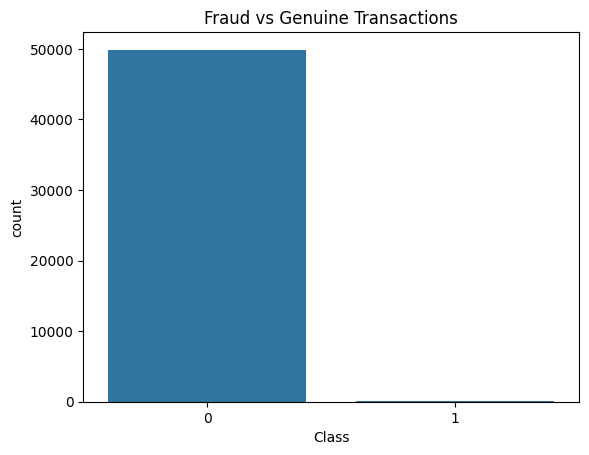

Class
0    0.998338
1    0.001662
Name: proportion, dtype: float64


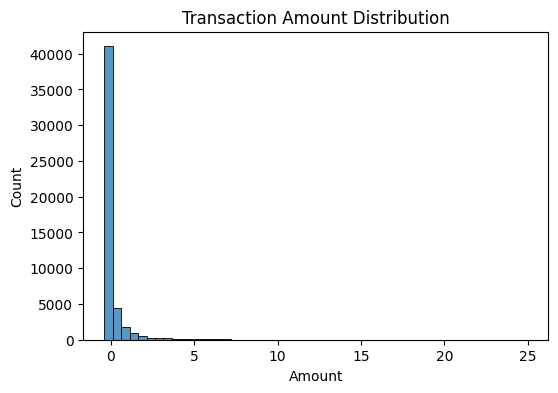

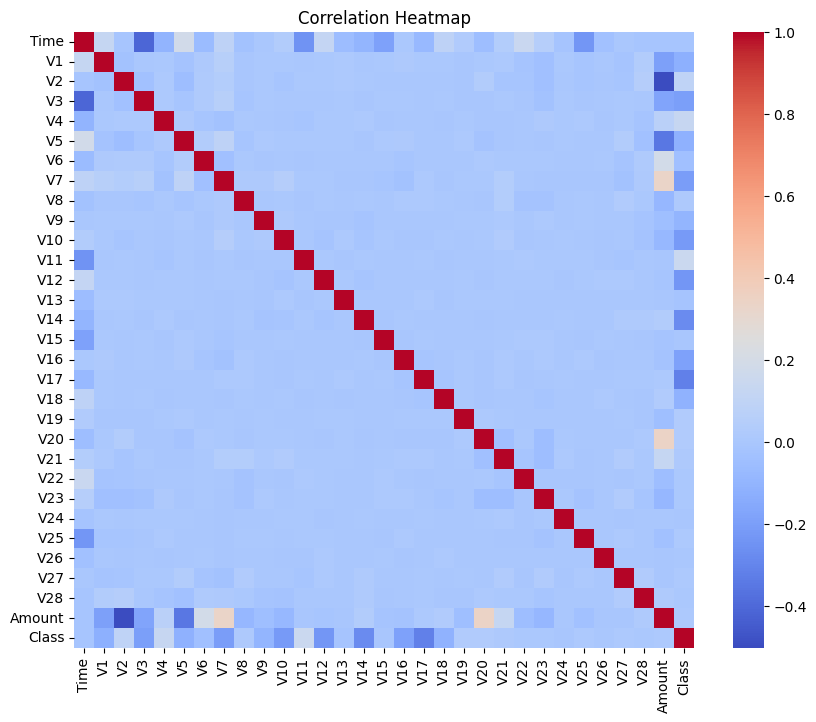

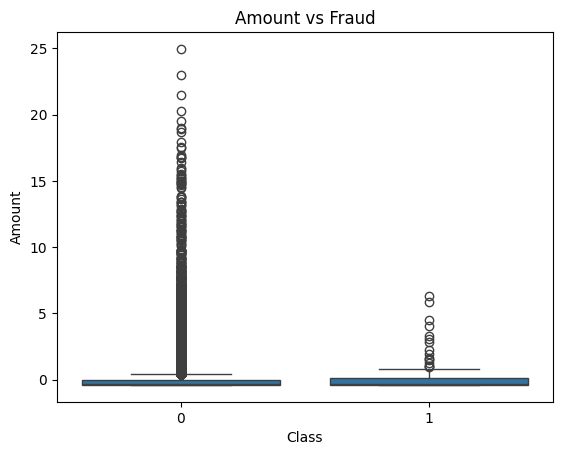

['scaler.pkl']

In [22]:
#class distribution
sns.countplot(x='Class', data=df)
plt.title("Fraud vs Genuine Transactions")
plt.show()

print(df['Class'].value_counts(normalize=True))

#Transaction amount distribution
plt.figure(figsize=(6,4))
sns.histplot(df['Amount'], bins=50)
plt.title("Transaction Amount Distribution")
plt.show()

#Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

#Fraud vs Amount boxplot
sns.boxplot(x='Class', y='Amount', data=df)
plt.title("Amount vs Fraud")
plt.show()

# Feature Scaling
from sklearn.preprocessing import StandardScaler
import joblib

scaler = StandardScaler()

df[['Time', 'Amount']] = scaler.fit_transform(df[['Time', 'Amount']])

joblib.dump(scaler, "scaler.pkl")


In [ ]:
#Train-test split
X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#handling imbalance
smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("After SMOTE:\n", y_train_res.value_counts())



After SMOTE:
 Class
0    39897
1    39897
Name: count, dtype: int64



Logistic Regression
              precision    recall  f1-score   support

           0       1.00      0.97      0.99      9974
           1       0.05      0.88      0.09        17

    accuracy                           0.97      9991
   macro avg       0.52      0.93      0.54      9991
weighted avg       1.00      0.97      0.98      9991


Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9974
           1       0.81      0.76      0.79        17

    accuracy                           1.00      9991
   macro avg       0.91      0.88      0.89      9991
weighted avg       1.00      1.00      1.00      9991

Epoch 1/5


d:\ML\CP_2\testenv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9341 - loss: 0.1862 - val_accuracy: 0.9905 - val_loss: 0.0459
Epoch 2/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9932 - loss: 0.0279 - val_accuracy: 1.0000 - val_loss: 0.0131
Epoch 3/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9977 - loss: 0.0139 - val_accuracy: 1.0000 - val_loss: 0.0067
Epoch 4/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9987 - loss: 0.0087 - val_accuracy: 1.0000 - val_loss: 0.0039
Epoch 5/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9990 - loss: 0.0061 - val_accuracy: 1.0000 - val_loss: 0.0023
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 581us/step

ANN Model
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9974
           1       0.56      0.82      0.67        17

    accuracy                           1.00      9991
   macro avg       0.78      0.91      0.83      9991
weighted avg       1.00      1.00      1.00      

d:\ML\CP_2\testenv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
d:\ML\CP_2\testenv\Lib\site-packages\keras\src\saving\saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 596us/step

===== Model Comparison Table =====
                  Model  Precision  Recall  F1 Score
0  Random Forest (Best)     0.8125  0.7647    0.7879
1                   ANN     0.5600  0.8235    0.6667
2             Tuned ANN     0.2188  0.8235    0.3457
3   Logistic Regression     0.0498  0.8824    0.0943


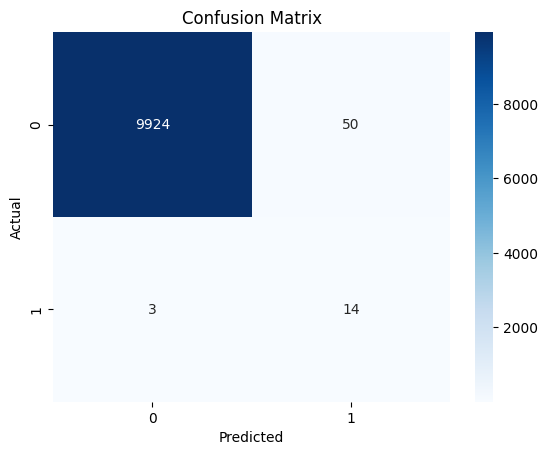

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 520us/step


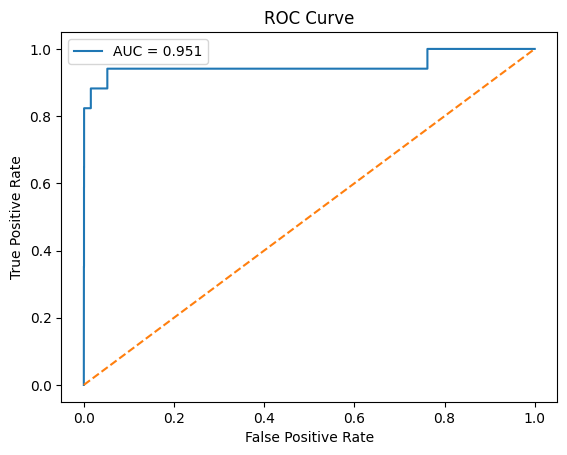

174/313 ━━━━━━━━━━━━━━━━━━━━ 0s 596us/step

d:\ML\CP_2\testenv\Lib\site-packages\keras\src\saving\saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'adam', because it has 14 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 641us/step

Loaded Model
              precision    recall  f1-score   support

           0       1.00      0.99      1.00      9974
           1       0.22      0.82      0.35        17

    accuracy                           0.99      9991
   macro avg       0.61      0.91      0.67      9991
weighted avg       1.00      0.99      1.00      9991



In [21]:
# Model building
#Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_res, y_train_res)

y_pred_lr = lr.predict(X_test)

print("\nLogistic Regression")
print(classification_report(y_test, y_pred_lr))

#Random Forest
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train_res, y_train_res)

y_pred_rf = rf.predict(X_test)

print("\nRandom Forest")
print(classification_report(y_test, y_pred_rf))

#Deep Learning Model
# ANN
ann = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

ann.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = ann.fit(
    X_train_res, y_train_res,
    epochs=5,
    batch_size=256,
    validation_split=0.2
)

y_pred_ann = (ann.predict(X_test) > 0.5).astype(int)

print("\nANN Model")
print(classification_report(y_test, y_pred_ann))

# Hyperparameter tuning with Keras Tuner
def build_model(hp):
    model = keras.Sequential()

    model.add(layers.Dense(
        units=hp.Int('units_1', 32, 128, step=32),
        activation='relu',
        input_shape=(X_train.shape[1],)
    ))

    model.add(layers.Dropout(
        hp.Float('dropout', 0.2, 0.5, step=0.1)
    ))

    model.add(layers.Dense(
        units=hp.Int('units_2', 16, 64, step=16),
        activation='relu'
    ))

    model.add(layers.Dense(1, activation='sigmoid'))

    model.compile(
        optimizer=keras.optimizers.Adam(
            hp.Choice('learning_rate', [1e-2, 1e-3, 1e-4])
        ),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=2,
    directory='tuner_dir',
    project_name='fraud_detection'
)

tuner.search(
    X_train_res, y_train_res,
    epochs=3,
    validation_split=0.2
)

#Best model evaluation
best_model = tuner.get_best_models(num_models=1)[0]

y_pred_tuned = (best_model.predict(X_test) > 0.5).astype(int)

# Comparision of models
results = []

# Logistic Regression
report_lr = classification_report(y_test, y_pred_lr, output_dict=True)
results.append({
    "Model": "Logistic Regression",
    "Precision": report_lr['1']['precision'],
    "Recall": report_lr['1']['recall'],
    "F1 Score": report_lr['1']['f1-score']
})

# Random Forest
report_rf = classification_report(y_test, y_pred_rf, output_dict=True)
results.append({
    "Model": "Random Forest",
    "Precision": report_rf['1']['precision'],
    "Recall": report_rf['1']['recall'],
    "F1 Score": report_rf['1']['f1-score']
})

# ANN
report_ann = classification_report(y_test, y_pred_ann, output_dict=True)
results.append({
    "Model": "ANN",
    "Precision": report_ann['1']['precision'],
    "Recall": report_ann['1']['recall'],
    "F1 Score": report_ann['1']['f1-score']
})

# Tuned ANN
report_tuned = classification_report(y_test, y_pred_tuned, output_dict=True)
results.append({
    "Model": "Tuned ANN",
    "Precision": report_tuned['1']['precision'],
    "Recall": report_tuned['1']['recall'],
    "F1 Score": report_tuned['1']['f1-score']
})

# ================================
# Create DataFrame
# ================================
results_df = pd.DataFrame(results)

# Round values for clean output
results_df = results_df.round(4)

# Sort by F1 Score
results_df = results_df.sort_values(by="F1 Score", ascending=False).reset_index(drop=True)

# ================================
# Highlight Best Model
# ================================
best_model_name = results_df.loc[0, "Model"]
results_df.loc[0, "Model"] = best_model_name + " (Best)"

# ================================
# Print Table
# ================================
print("\n===== Model Comparison Table =====")
print(results_df)

# Confusion matrix for the best model
cm = confusion_matrix(y_test, y_pred_tuned)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC curve for the best model
from sklearn.metrics import roc_curve, roc_auc_score

y_pred_prob = best_model.predict(X_test)

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
auc = roc_auc_score(y_test, y_pred_prob)

import matplotlib.pyplot as plt

plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# Save the best model
best_model.save("best_model.keras")

# Load model
loaded_model = keras.models.load_model("best_model.keras")
# Evaluate the loaded model
y_pred_loaded = (loaded_model.predict(X_test) > 0.5).astype(int)

print("\nLoaded Model")
print(classification_report(y_test, y_pred_loaded))


